# 🏦 Bank Customer Churn Prediction

## Business Context

Customer churn — when a customer closes their accounts and moves to a competitor — 
is one of the most costly challenges facing retail banks. Acquiring a new customer 
costs 5-7x more than retaining an existing one, making early churn detection a 
high-priority analytics problem.

This project builds an end-to-end churn prediction pipeline for a bank with 10,000 
customers and a 20% churn rate — significantly above the industry average of 10-15%, 
indicating a real retention problem worth solving.

## Goal
Predict which customers are likely to churn so the retention team can intervene 
proactively — offering personalised incentives, outreach calls, or product upgrades 
before the customer leaves.

## Dataset
- 10,000 bank customers across France, Germany and Spain
- 14 features including demographics, account activity and product usage
- Target variable: `Exited` (1 = churned, 0 = stayed)
- Source: [Kaggle Bank Customer Churn Dataset](https://www.kaggle.com/datasets/shantanudhakadd/bank-customer-churn-prediction)

## Summary

We load 10,000 customer records and find a churn rate of 20.37% with no missing 
values — a clean dataset ready for modelling.

We drop RowNumber, CustomerId and Surname as these are identifiers with no 
predictive value. Geography and Gender are encoded as dummy variables with 
reference groups to avoid multicollinearity.

Data is split 80/20 into train and test sets using stratified sampling to preserve 
the class ratio across both sets.

We compare three models — Logistic Regression (ROC-AUC: 0.74), Random Forest 
(0.85) and XGBoost (0.87) — selecting XGBoost as the best performer.

XGBoost is tuned using two rounds of GridSearchCV, first optimising core parameters 
then regularisation. Final parameters: max_depth=5, learning_rate=0.1, 
reg_lambda=10, scale_pos_weight=3.93. Final ROC-AUC: 0.8705, Recall: 74%.

Feature importance reveals NumOfProducts, IsActiveMember and Age as the strongest 
churn predictors — inactive customers with few products are at highest risk.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay
)
import statsmodels.api as sm
from xgboost import XGBClassifier



In [2]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost'])

CompletedProcess(args=['pip', 'install', 'xgboost'], returncode=0)

In [4]:
import pandas as pd

df = pd.read_csv('C:/Users/Ideapad5/OneDrive/Documents/Projects/bank_churn/data/Churn_Modelling.csv')
print(df.shape)
print(df.head())


(10000, 14)
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4

In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
print(df['Exited'].value_counts())
print(df['Exited'].value_counts(normalize=True))

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


In [7]:
# Drop identifier columns
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Create dummy variables — fill in the categorical columns
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

print(df.columns.tolist())
print(df.shape)

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
(10000, 12)


In [8]:
X = df.drop(columns=['Exited'])
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20, stratify=y
)

print(f'Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')
print(f'Churn in train: {y_train.sum()} | Churn in test: {y_test.sum()}')

Train size: 8,000 | Test size: 2,000
Churn in train: 1630 | Churn in test: 407


In [9]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

c:\Users\Ideapad5\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [10]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f'\n{'='*50}')
    print(f'  {model_name}')
    print(f'{'='*50}')
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))
    print(f'ROC-AUC:              {roc_auc_score(y_test, y_prob):.4f}')
    print(f'Avg Precision (PR):   {average_precision_score(y_test, y_prob):.4f}')
    return y_pred, y_prob

lr_pred, lr_prob = evaluate_model(lr, X_test, y_test, 'Logistic Regression')


  Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.89      0.67      0.77      1593
     Churned       0.34      0.67      0.45       407

    accuracy                           0.67      2000
   macro avg       0.62      0.67      0.61      2000
weighted avg       0.78      0.67      0.70      2000

ROC-AUC:              0.7385
Avg Precision (PR):   0.4285


In [11]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0],
    'Odds Ratio': np.exp(lr.coef_[0])
}).sort_values('Odds Ratio', ascending=False)

print(coefficients)

              Feature   Coefficient  Odds Ratio
8   Geography_Germany  9.304895e-01    2.535750
9     Geography_Spain  9.770065e-02    1.102633
1                 Age  7.074344e-02    1.073306
3             Balance  1.734472e-06    1.000002
7     EstimatedSalary -8.361493e-08    1.000000
0         CreditScore -2.233181e-03    0.997769
2              Tenure -2.278784e-02    0.977470
4       NumOfProducts -1.716279e-01    0.842293
5           HasCrCard -1.904928e-01    0.826552
10        Gender_Male -5.728302e-01    0.563927
6      IsActiveMember -9.370497e-01    0.391782


In [ ]:
bool_cols = ['Geography_Germany', 'Geography_Spain', 'Gender_Male']
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

X_train_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.424550
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 Exited   No. Observations:                 8000
Model:                          Logit   Df Residuals:                     7988
Method:                           MLE   Df Model:                           11
Date:                Thu, 19 Mar 2026   Pseudo R-squ.:                  0.1602
Time:                        12:52:41   Log-Likelihood:                -3396.4
converged:                       True   LL-Null:                       -4044.5
Covariance Type:            nonrobust   LLR p-value:                3.076e-271
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -3.4885      0.276    -12.660      0.000      -4.029      -2.948
CreditSc

In [15]:
#Test Random forrests and XGBoost for better ROC-AUC

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
xgb = XGBClassifier(n_estimators= 100, learning_rate = 0.1, random_state=42)

rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [17]:
rf_pred, rf_prob = evaluate_model(rf, X_test, y_test, 'Random Forrest')

xgb_pred, xgb_prob = evaluate_model(xgb, X_test, y_test, 'XGBoost')


  Random Forrest
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
     Churned       0.81      0.43      0.56       407

    accuracy                           0.86      2000
   macro avg       0.84      0.70      0.74      2000
weighted avg       0.86      0.86      0.85      2000

ROC-AUC:              0.8462
Avg Precision (PR):   0.6874

  XGBoost
              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92      1593
     Churned       0.75      0.46      0.57       407

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000

ROC-AUC:              0.8662
Avg Precision (PR):   0.7046


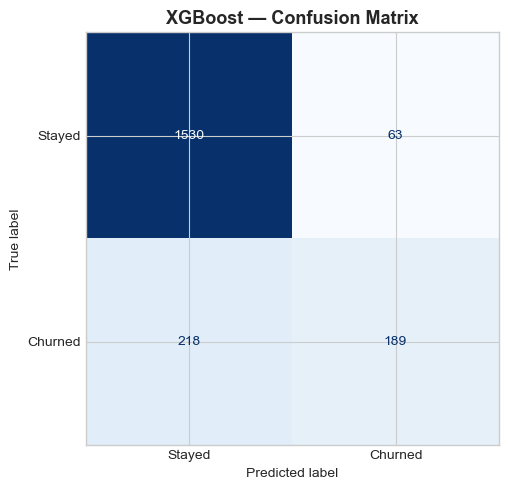

In [26]:
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, xgb_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('XGBoost — Confusion Matrix', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('../figures/confusion_matrix_xgb.png', dpi=150)
plt.show()

In [ ]:
#Only changing the classification threshold

for threshold in [0.25, 0.20, 0.15]:
    pred = (xgb_prob >= threshold).astype(int)
    report = classification_report(y_test, pred, output_dict=True)
    print(f"Threshold {threshold} — Recall: {report['1']['recall']:.2%} | Precision: {report['1']['precision']:.2%}")

Threshold 0.25 — Recall: 69.78% | Precision: 55.69%
Threshold 0.2 — Recall: 73.22% | Precision: 50.59%
Threshold 0.15 — Recall: 81.82% | Precision: 44.88%


In [32]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200]
}

grid_search = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale, random_state=42),
    param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


In [48]:
#Changing paramters for better results

scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale:.2f}')

xgb_tuned = XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    gamma=0,
    reg_lambda=10,
    scale_pos_weight=scale,
    random_state=42
)
xgb_tuned.fit(X_train, y_train)
xgb_tuned_pred, xgb_tuned_prob = evaluate_model(xgb_tuned, X_test, y_test, 'XGBoost Tuned')

scale_pos_weight: 3.91

  XGBoost Tuned
              precision    recall  f1-score   support

      Stayed       0.93      0.82      0.87      1593
     Churned       0.52      0.74      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000

ROC-AUC:              0.8705
Avg Precision (PR):   0.7111


In [38]:
param_grid_2 = {
    'gamma': [0, 0.25, 1.0],
    'reg_lambda': [0, 1.0, 10.0],
}

grid_search_2 = GridSearchCV(
    XGBClassifier(
        scale_pos_weight=scale,
        learning_rate=0.1,
        max_depth=4,
        n_estimators=100,
        random_state=42
    ),
    param_grid_2,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_2.fit(X_train, y_train)
print(grid_search_2.best_params_)
print(f'Best ROC-AUC: {grid_search_2.best_score_:.4f}')

Fitting 5 folds for each of 9 candidates, totalling 45 fits
{'gamma': 0, 'reg_lambda': 10.0}
Best ROC-AUC: 0.8644


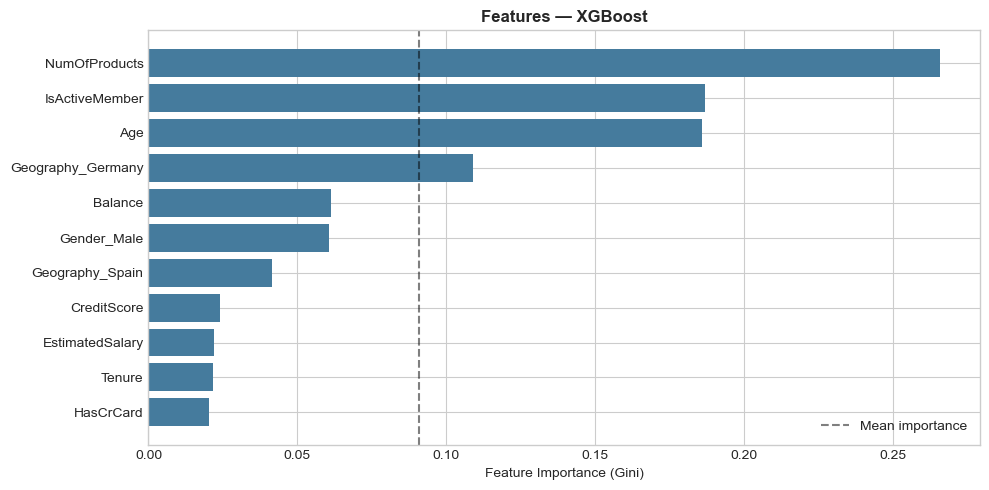

In [51]:
#Feature importance based on XGBoost

importances = pd.Series(xgb_tuned.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(importances.index[::-1], importances.values[::-1],
               color=['#E63946' if i < 3 else '#457B9D' for i in range(14, -1, -1)])
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Features — XGBoost', fontweight='bold')
ax.axvline(importances.mean(), color='black', linestyle='--', alpha=0.5, label='Mean importance')
ax.legend()
plt.tight_layout()
plt.show()

## Final Results & Recommendations

The final XGBoost model achieves a ROC-AUC of 0.8705 and correctly identifies 
74% of customers who will churn (recall). This comes at the cost of lower precision 
(52%) — meaning roughly 1 in 2 flagged customers won't actually churn. This 
trade-off is acceptable in a banking context where the cost of losing a customer 
far outweighs the cost of an unnecessary retention call.

## Retention Team Recommendations

Based on feature importance and model coefficients, prioritise outreach to customers who are:
- Located in **Germany** — highest churn rate by geography
- **Older** — age is the third strongest predictor
- **Inactive members** — not engaging with the bank's products
- Have **only 1 product** — low switching cost
- **Female** — women churn at higher rates than men in this dataset

Note: NumOfProducts shows a non-linear relationship with churn that logistic 
regression cannot fully capture. Customers with 3-4 products churn at 83-100% 
rates, suggesting over-selling products is a key driver of dissatisfaction. 
This non-linearity explains why XGBoost significantly outperforms logistic regression.